<body>
  <h1>Analyzing the Relationship Between Age and Income</h1>
  
  <h2>Business Problem Statement</h2>
  <p>Many organizations struggle to identify key demographic factors influencing income distribution. This analysis can help HR teams better understand income demographics.</p>
  
  <h2>What to Do:</h2>
  <ul>
    <li>Load a demographic dataset (e.g., age, income, education levels).</li>
    <li>Explore the relationship between age and income using visualization methods like scatter plots.</li>
    <li>Analyze correlations using statistical methods such as Pearson's correlation.</li>
    <li>Summarize findings with key insights and visualizations.</li>
  </ul>
</body>

In [286]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn 
import plotly.express as px

In [287]:
# import the dataset 
dataset = pd.read_csv("adult.csv")

In [288]:
dataset.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [289]:
# Shape of the dataset 

dataset.shape

(32561, 15)

# Type casting 

In [290]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [291]:
dataset.income.value_counts()

<=50K    24720
>50K      7841
Name: income, dtype: int64

In [292]:
# less than 50  = 0 
# Greater tham 50 = 1
dataset['income'] = dataset['income'].replace({"<=50K":0, ">50K":1})

In [293]:
dataset.income.dtype

dtype('int64')

# Missing value 

In [294]:
# Check for any null values having
dataset.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [295]:
# There is no null value but having question marks (?)

In [296]:
# workclass, occupation 
dataset['workclass'].value_counts()

Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: workclass, dtype: int64

In [297]:
# workclass, occupation 
dataset['occupation'].value_counts()

Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: occupation, dtype: int64

In [298]:
# native.country
dataset['native.country'].value_counts()

United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                      

In [299]:
# Fill the question marks using the mode imputer 
from sklearn.impute import SimpleImputer

In [300]:
modeImputer = SimpleImputer(missing_values="?", strategy="most_frequent")

dataset['workclass'] = pd.DataFrame(modeImputer.fit_transform(dataset[['workclass']]))
dataset['occupation'] = pd.DataFrame(modeImputer.fit_transform(dataset[['occupation']]))
dataset['native.country'] = pd.DataFrame(modeImputer.fit_transform(dataset[['native.country']]))

In [301]:
dataset.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0


# let's torture the categorical variable 

In [302]:
categoricalColumn = [column for column in dataset.columns if dataset[column].dtype == 'O']

In [303]:
dataset[categoricalColumn].nunique()

workclass          8
education         16
marital.status     7
occupation        14
relationship       6
race               5
sex                2
native.country    41
dtype: int64

In [304]:
# Reduce categorize or replace categorize 

#### WorkClass 

In [305]:
dataset['workclass'].value_counts()

Private             24532
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: workclass, dtype: int64

In [306]:
dataset['workclass'].replace(["State-gov", 'Local-gov', 'Federal-gov'], "Goverment-job", inplace = True)
dataset['workclass'].replace(["Self-emp-inc", 'Self-emp-not-inc'], "self-employe", inplace = True)
dataset['workclass'].replace(["Never-worked", 'Without-pay'], "Job-Less", inplace = True)

In [307]:
dataset['workclass'].value_counts()

Private          24532
Goverment-job     4351
self-employe      3657
Job-Less            21
Name: workclass, dtype: int64

#### education

In [308]:
dataset['education'].value_counts()

HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: education, dtype: int64

In [309]:
dataset['education'].replace(['10th', '11th', '7th-8th', '9th', '12th', '5th-6th', '1st-4th', 'Preschool'], "School", inplace = True)
dataset['education'].replace('HS-grad', "High-School", inplace = True)
dataset['education'].replace('Bachelors', "Undergraduate", inplace = True)
dataset['education'].replace('Masters', "Graduate", inplace = True)
dataset['education'].replace(['Some-college', 'Prof-school', 'Assoc-voc', 'Assoc-acdm'], "Higher", inplace = True)

In [310]:
dataset['education'].value_counts()

High-School      10501
Higher           10316
Undergraduate     5355
School            4253
Graduate          1723
Doctorate          413
Name: education, dtype: int64

#### marital status 

In [311]:
dataset['marital.status'].value_counts()

Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: marital.status, dtype: int64

In [312]:
dataset['marital.status'].replace(['Married-civ-spouse', 'Married-AF-spouse'], "married", inplace = True)
dataset['marital.status'].replace(['Never-married'], "not-married", inplace = True)
dataset['marital.status'].replace(['Married-spouse-absent', 'Divorced', 'Separated', 'Widowed'], "Other", inplace = True)

In [313]:
dataset['marital.status'].value_counts()

married        14999
not-married    10683
Other           6879
Name: marital.status, dtype: int64

In [314]:
dataset['occupation'].value_counts()

Prof-specialty       5983
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: occupation, dtype: int64

In [315]:
dataset

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,High-School,9,Other,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,High-School,9,Other,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,Private,186061,Higher,10,Other,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,140359,School,4,Other,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Higher,10,Other,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Higher,10,not-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,0
32557,27,Private,257302,Higher,12,married,Tech-support,Wife,White,Female,0,0,38,United-States,0
32558,40,Private,154374,High-School,9,married,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32559,58,Private,151910,High-School,9,Other,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0


In [316]:
dataset.corr()

C:\Users\User\AppData\Local\Temp\ipykernel_16160\2191645083.py:1: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756,0.234037
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768,-0.009463
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123,0.335154
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409,0.223329
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256,0.150526
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000,0.229689
income,0.234037,-0.009463,0.335154,0.223329,0.150526,0.229689,1.000000


In [317]:
# Remove the unwanted colum

In [318]:
dataset.drop(['fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'native.country'], axis=1, inplace=True)

In [319]:
# 'fnlwgt': Remove (population weight, not useful for prediction).
# 'education.num': Remove (only a numerical representation without meaning).
# 'capital.gain', 'capital.loss': Remove (zero variance).
# 'native.country': Remove (irrelevant for analysis).

In [320]:
# Final dataset 

In [321]:
dataset.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,income
0,90,Private,High-School,Other,Prof-specialty,Not-in-family,White,Female,40,0
1,82,Private,High-School,Other,Exec-managerial,Not-in-family,White,Female,18,0
2,66,Private,Higher,Other,Prof-specialty,Unmarried,Black,Female,40,0
3,54,Private,School,Other,Machine-op-inspct,Unmarried,White,Female,40,0
4,41,Private,Higher,Other,Prof-specialty,Own-child,White,Female,40,0


# Explotary data analysis 

In [322]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0
income,32561.0,0.240810,0.427581,0.0,0.0,0.0,0.0,1.0


### 1 Which age category of people earns the highest salary?

In [323]:
bins = [0, 20, 30, 40, 50, 60, 70, 100]

labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']

dataset['age_category'] = pd.cut(dataset['age'], bins = bins, labels = labels) 

ageCategory = dataset.groupby(['age_category', 'income']).size().reset_index(name='count')

ageCategory['income_label'] = ageCategory['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

In [324]:
ageCategory.head()

,age_category,income,count,income_label
0,<20,0,2408,Less than or equal to 50K
1,<20,1,2,Greater than 50K
2,20-30,0,7482,Less than or equal to 50K
3,20-30,1,680,Greater than 50K
4,30-40,0,6140,Less than or equal to 50K


Text(0.5, 1.0, 'Which age category of people earns the highest salary')

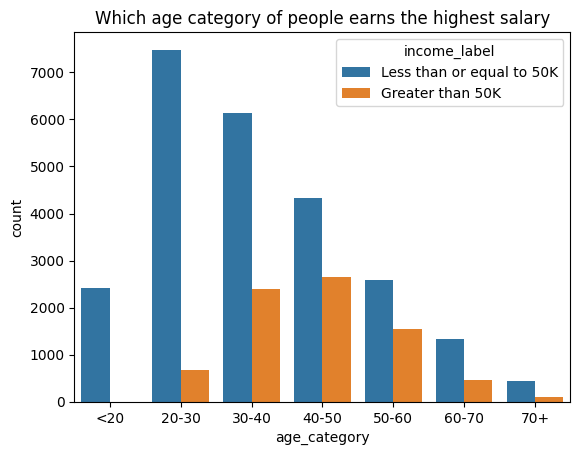

In [371]:
sns.barplot(y="count", x="age_category", data=ageCategory, hue="income_label")
plt.title("Which age category of people earns the highest salary")

# 2 Which type of occupation earns the highest salary?

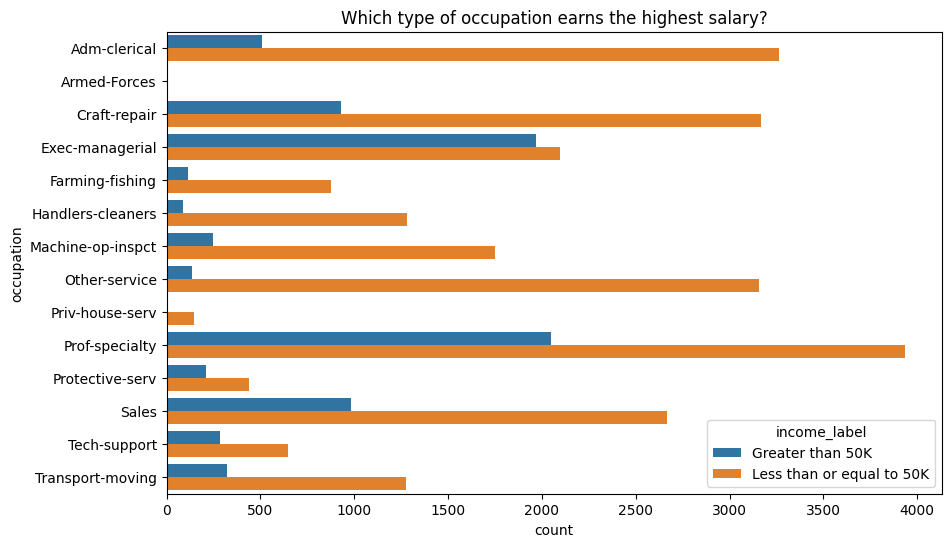

In [372]:
dataset['income_label'] = dataset['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

income_by_occupation = dataset.groupby(['occupation', 'income_label']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(x="count", y="occupation", hue="income_label", data=income_by_occupation)
plt.title("Which type of occupation earns the highest salary?")
plt.show()

### 3 How many hours per week result in earning the highest income?

In [327]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
dataset['hours_bin'] = pd.cut(dataset['hours.per.week'], bins=bins, labels=labels)

dataset['income_label'] = dataset['income'].map({0: 'less than or equal 50 k', 1: 'greater than 50 k'})

In [328]:
income_by_hours = dataset.groupby(['hours_bin', 'income_label']).size().reset_index(name='count')
income_by_hours.head()

,hours_bin,income_label,count
0,0-20,greater than 50 k,195
1,0-20,less than or equal 50 k,2733
2,21-40,greater than 50 k,3790
3,21-40,less than or equal 50 k,16262
4,41-60,greater than 50 k,3452


Text(0.5, 1.0, 'How many hours per week result in earning the highest salary?')

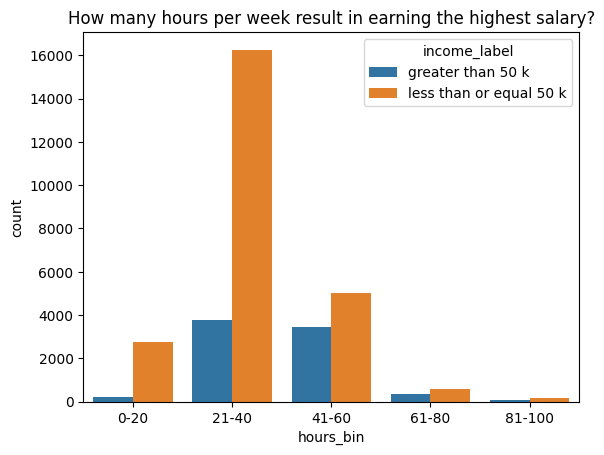

In [373]:
sns.barplot(y="count", x="hours_bin", data=income_by_hours, hue="income_label")
plt.title("How many hours per week result in earning the highest salary?")

#### 4 Which categories of occupations and working hours are linked to higher income

In [334]:
income_high = dataset[dataset['income'] == 1]

In [347]:
heatmap_data = income_high.pivot_table(index='occupation', columns='hours_bin', values='income', aggfunc='count', fill_value=0)
heatmap_data.head()

hours_bin,0-20,21-40,41-60,61-80,81-100
occupation,,,,,
Adm-clerical,24,354,122,7,0
Armed-Forces,0,1,0,0,0
Craft-repair,7,534,358,24,6
Exec-managerial,26,757,1077,94,14
Farming-fishing,2,32,57,17,7


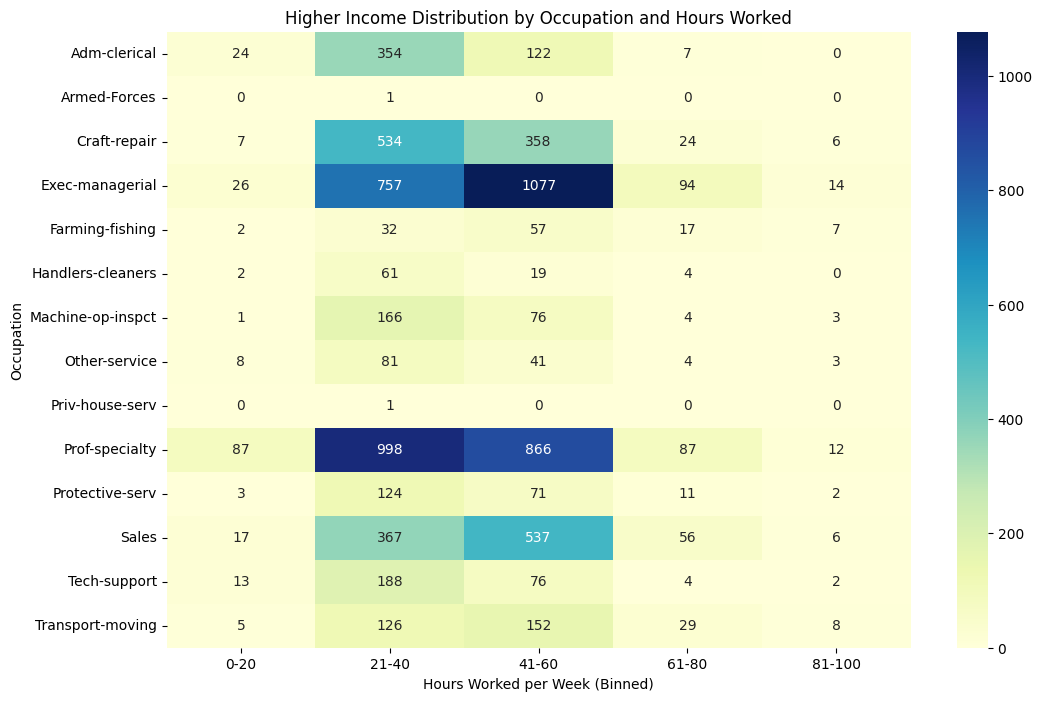

In [346]:
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title("Higher Income Distribution by Occupation and Hours Worked")
plt.xlabel("Hours Worked per Week (Binned)")
plt.ylabel("Occupation")
plt.show()

#### 5 Which work class earns the highest income?

In [354]:
workclass = dataset.groupby(['workclass', 'income']).size().reset_index(name = "count")

workclass["income_lable"] = workclass['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

Text(0.5, 1.0, 'Which work class earns the highest income')

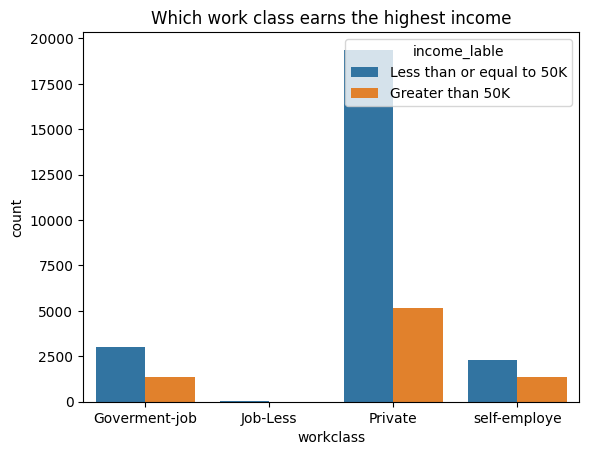

In [374]:
sns.barplot(y="count", x="workclass", data=workclass, hue="income_lable")
plt.title("Which work class earns the highest income")

#### 6 Which education level earns the highest salary

In [356]:
education = dataset.groupby(['education', 'income']).size().reset_index(name = "count")

education["income_lable"] = education['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

Text(0.5, 1.0, 'Which education level earns the highest salary')

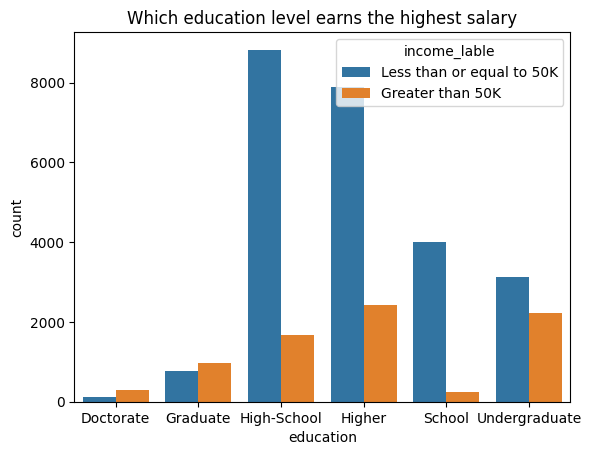

In [375]:
sns.barplot(y="count", x="education", data=education, hue="income_lable")
plt.title("Which education level earns the highest salary")

#### 7 Is there any relation between relationship status and income?

In [358]:
relationship = dataset.groupby(['relationship', 'income']).size().reset_index(name = "count")

relationship["income_lable"] = relationship['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

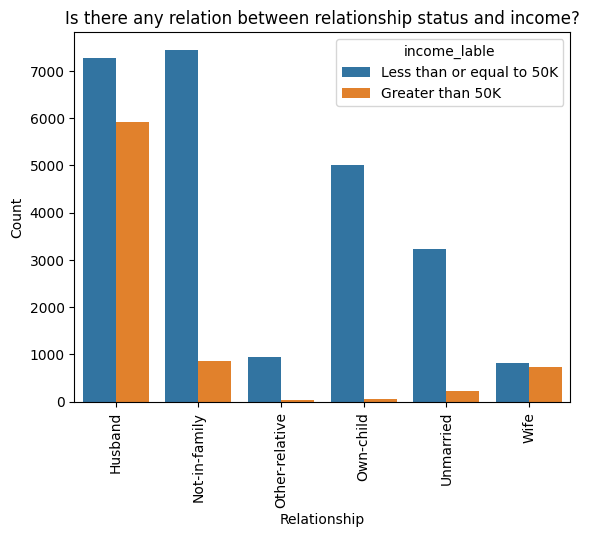

In [376]:
sns.barplot(y="count", x="relationship", data=relationship, hue="income_lable")
plt.title("Is there any relation between relationship status and income?")
plt.xlabel("Relationship")  
plt.ylabel("Count")
plt.xticks(rotation=90)  
plt.show()

#### 8 Is there any relation between marital status and income?

In [364]:
marital = dataset.groupby(['marital.status', 'income']).size().reset_index(name = "count")

marital["income_lable"] = marital['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

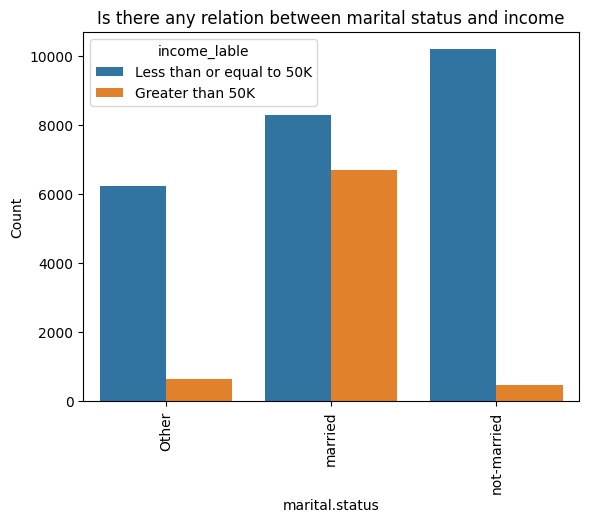

In [379]:
sns.barplot(y="count", x="marital.status", data=marital, hue="income_lable")
plt.title("Is there any relation between marital status and income")  
plt.ylabel("Count")
plt.xticks(rotation=90)  
plt.show()

#### 9 Is there any relationship between race and income?

In [369]:
race = dataset.groupby(['race', 'income']).size().reset_index(name = "count")

race["income_lable"] = race['income'].map({0: 'Less than or equal to 50K', 1: 'Greater than 50K'})

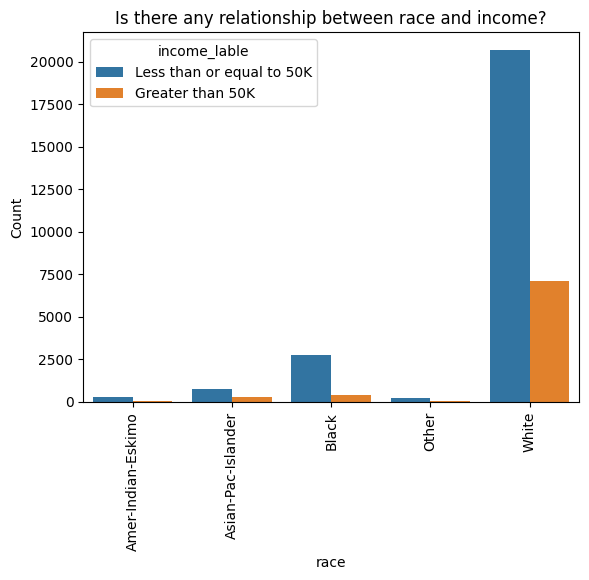

In [380]:
sns.barplot(y="count", x="race", data=race, hue="income_lable")
plt.title("Is there any relationship between race and income?")
plt.xlabel("race")  
plt.ylabel("Count")
plt.xticks(rotation=90)  
plt.show()